# Porto and Lisbon Urban Heat Island Exposure and Population Characteristics

This notebook reads the prepared real-data table for **Lisbon** and **Porto** and reproduces the core exposure and representation metrics used throughout this project.

The question is narrow by design:

> Which groups are more or less represented in cells with stronger modelled urban heat island intensity?


## Sources and interpretation

This analysis combines three official or near-official inputs:

- the **Eurostat GISCO Census 2021 1 km grid** for total population, children, older residents, employed residents, and people born outside the EU;
- the **Eurostat GISCO Urban Audit `CITIES` polygons** for Lisbon and Porto;
- the **EEA public service exposing the Copernicus/UrbClim urban heat island model**.

Two interpretation points matter before reading the results:

1. The Urban Audit `CITIES` polygons are **not municipality boundaries**, so the city totals here are larger than the municipality-only populations many readers expect.
2. Some coastal or no-data fragments do not return a direct UHI pixel value from the public service. Those fragments were filled with the nearest non-missing value within the same city during the preparation step, and that assumption is documented in `data/SOURCES.md`.


## Method

This notebook works from the prepared table rather than rebuilding the geospatial pipeline inline.

At a high level, the preparation workflow does this:

1. Intersect the Eurostat 1 km grid with the Lisbon and Porto Urban Audit city polygons.
2. Apply area weights when a grid cell is split by a city boundary.
3. Attach one UHI intensity value to each resulting fragment.
4. Mark fragments as exposed when `uhi_intensity_celsius >= 2.0` by default.
5. Compare each group's share in the whole city with its share inside exposed fragments.


In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import numpy as np
import pandas as pd
from IPython.display import Image, display

from uhi_exposure.io import load_exposure_cells, write_dataframe
from uhi_exposure.metrics import (
    compute_city_exposure_summary,
    compute_dose_response,
    compute_double_burden,
    compute_exposure_band_decomposition,
    compute_group_representation,
    compute_group_representation_by_threshold,
    compute_threshold_sensitivity,
    bootstrap_group_representation,
)
from uhi_exposure.plotting import (
    plot_exposed_population_share,
    plot_dose_response,
    plot_exposure_band_decomposition,
    plot_group_share_comparison,
    plot_group_threshold_small_multiples,
    plot_hotspot_map,
    plot_population_uhi_band_comparison,
    plot_population_weighted_uhi_distribution,
    plot_representation_heatmap,
    plot_representation_with_ci,
    plot_representation_ratios,
    plot_threshold_sensitivity,
)
from uhi_exposure.spatial import prepared_cells_to_geodataframe


## Configuration

The notebook is configured for the real prepared table by default.

Change the threshold only if you want to test a different exposure definition. Keep in mind that a higher threshold can materially reduce the exposed population share, especially in Lisbon with the current source combination.


In [2]:
USE_DEMO = False
UHI_THRESHOLD_CELSIUS = 2.0
REAL_DATA_PATH = PROJECT_ROOT / "data" / "manual" / "porto_lisbon_cells.csv"
DEMO_DATA_PATH = PROJECT_ROOT / "data" / "demo" / "porto_lisbon_demo_cells.csv"
INPUT_PATH = DEMO_DATA_PATH if USE_DEMO else REAL_DATA_PATH
OUTPUT_DIR = PROJECT_ROOT / "outputs"
PLOT_DIR = PROJECT_ROOT / "plots"

print(f"Using input: {INPUT_PATH}")
print(f"UHI threshold: {UHI_THRESHOLD_CELSIUS:.1f} °C")


Using input: C:\Users\diogo\work_code\ds-projects-portfolio\projects\porto_lisbon_uhi_exposure\data\manual\porto_lisbon_cells.csv
UHI threshold: 2.0 °C


## Load the prepared cell-level table

This cell reads the prepared CSV and shows the first rows so you can verify the schema and the expected fractional counts from area weighting.

Expected columns:

```text
city,cell_id,population_total,age_0_14,age_65_plus,employed,born_outside_eu,uhi_intensity_celsius,is_uhi_exposed
```


In [3]:
cells = load_exposure_cells(INPUT_PATH)
cells.head()

,city,cell_id,population_total,age_0_14,age_65_plus,employed,born_outside_eu,uhi_intensity_celsius,is_uhi_exposed
0,Lisbon,CRS3035RES1000mN1929000E2657000,0.000000,0.000000,0.000000,0.000000,0.000000,0.140198,False
1,Lisbon,CRS3035RES1000mN1933000E2674000,0.658670,0.099566,0.107225,0.245087,0.045954,1.645599,False
2,Lisbon,CRS3035RES1000mN1930000E2674000,1.879807,0.244013,0.478989,0.759153,0.126525,1.669006,False
3,Lisbon,CRS3035RES1000mN1929000E2674000,3.050808,0.435830,0.174332,1.220323,0.087166,1.477478,False
4,Lisbon,CRS3035RES1000mN1925000E2668000,29.370680,3.012377,6.150271,14.434308,4.769598,1.265320,False


In [4]:
cells.groupby("city", as_index=False).agg(
    cells=("cell_id", "count"),
    total_population=("population_total", "sum"),
    mean_uhi=("uhi_intensity_celsius", "mean"),
    max_uhi=("uhi_intensity_celsius", "max"),
)

,city,cells,total_population,mean_uhi,max_uhi
0,Lisbon,793,1.850999e+06,0.714196,2.234589
1,Porto,585,9.583587e+05,1.110140,2.300751


## City-level exposure summary

This table answers the first high-level question: how much of each city's population sits above the current UHI threshold?

Read it together with the mean and exposed-area mean. A city can have a modest average UHI level and still have a meaningful hot tail, or vice versa.


In [5]:
city_summary = compute_city_exposure_summary(cells, threshold=UHI_THRESHOLD_CELSIUS)
city_summary

,city,total_population,exposed_population,exposed_population_share,mean_uhi_intensity_celsius,mean_uhi_intensity_exposed_celsius
0,Lisbon,1.850999e+06,19518.178566,0.010545,1.030735,2.121989
1,Porto,9.583587e+05,61532.000000,0.064206,1.507904,2.095122


## UHI distribution and threshold context

Before focusing only on a `2.0 °C` cutoff, it helps to inspect the full distribution. These quantiles show how much warmer Porto is across the upper half of the distribution, not only at the extreme tail.


In [6]:
uhi_distribution = (
    cells.groupby("city")["uhi_intensity_celsius"]
    .quantile([0.0, 0.1, 0.25, 0.5, 0.75, 0.9, 1.0])
    .unstack()
    .rename(
        columns={
            0.0: "min",
            0.1: "p10",
            0.25: "p25",
            0.5: "median",
            0.75: "p75",
            0.9: "p90",
            1.0: "max",
        }
    )
)

uhi_distribution.round(3)

,min,p10,p25,median,p75,p90,max
city,,,,,,,
Lisbon,-1.026,-0.185,0.159,0.710,1.325,1.711,2.235
Porto,-0.550,0.204,0.795,1.222,1.497,1.734,2.301


## Population across UHI bands

The next table shifts the unit from *cells* to *people*. This is more informative because some fragments are almost unpopulated while others contain a large share of each city's residents.


In [7]:
uhi_band_bins = [-np.inf, 0.0, 0.5, 1.0, 1.5, 2.0, np.inf]
uhi_band_labels = ["<0.0", "0.0-0.5", "0.5-1.0", "1.0-1.5", "1.5-2.0", ">=2.0"]

uhi_band_summary = (
    cells.assign(
        uhi_band=pd.cut(
            cells["uhi_intensity_celsius"],
            bins=uhi_band_bins,
            labels=uhi_band_labels,
            right=False,
        )
    )
    .groupby(["city", "uhi_band"], observed=False)["population_total"]
    .sum()
    .rename("population_in_band")
    .reset_index()
)

city_totals = cells.groupby("city")["population_total"].sum().rename("city_total_population")
uhi_band_summary = uhi_band_summary.merge(city_totals, on="city", how="left")
uhi_band_summary["population_share_in_band"] = (
    uhi_band_summary["population_in_band"] / uhi_band_summary["city_total_population"]
)

uhi_band_summary.pivot(index="uhi_band", columns="city", values="population_share_in_band").round(3)

city,Lisbon,Porto
uhi_band,,
<0.0,0.075,0.001
0.0-0.5,0.121,0.017
0.5-1.0,0.204,0.093
1.0-1.5,0.370,0.298
1.5-2.0,0.219,0.527
>=2.0,0.011,0.064


## Group representation in exposed areas

This table compares each group's share in the whole city with its share inside exposed fragments.

- A **representation ratio above 1** means overrepresentation in exposed areas.
- A **representation ratio below 1** means underrepresentation in exposed areas.
- The percentage-point difference is often easier to read than the ratio when the baseline group share is small.


In [8]:
representation = compute_group_representation(cells, threshold=UHI_THRESHOLD_CELSIUS)
representation.sort_values(["city", "representation_ratio"], ascending=[True, False])

,city,group,city_group_count,exposed_group_count,city_group_share,exposed_group_share,difference_percentage_points,representation_ratio,is_overrepresented
3,Lisbon,born_outside_eu,2.842576e+05,4794.454585,0.153570,0.245640,9.207067,1.599536,True
2,Lisbon,not_employed,1.049505e+06,11677.865529,0.566994,0.598307,3.131362,1.055227,True
0,Lisbon,children_0_14,2.592130e+05,2860.390920,0.140039,0.146550,0.651063,1.046491,True
1,Lisbon,older_65_plus,4.211565e+05,4052.274713,0.227529,0.207615,-1.991385,0.912478,False
7,Porto,born_outside_eu,6.081594e+04,4453.000000,0.063458,0.072369,0.891042,1.140413,True
5,Porto,older_65_plus,2.161447e+05,15677.000000,0.225536,0.254778,2.924172,1.129654,True
6,Porto,not_employed,5.506193e+05,38353.000000,0.574544,0.623302,4.875764,1.084863,True
4,Porto,children_0_14,1.189934e+05,6832.000000,0.124164,0.111032,-1.313204,0.894236,False


## Compact interpretation table

This condensed table is useful for writing, but it hides part of the story. The next sections unpack the underlying UHI distribution and the threshold sensitivity that sit behind the binary exposed/not-exposed split.


In [9]:
interpretation = representation.assign(
    city_group_share_pct=lambda df: 100 * df["city_group_share"],
    exposed_group_share_pct=lambda df: 100 * df["exposed_group_share"],
).loc[
    :,
    [
        "city",
        "group",
        "city_group_share_pct",
        "exposed_group_share_pct",
        "difference_percentage_points",
        "representation_ratio",
        "is_overrepresented",
    ],
]

interpretation.round(2)

,city,group,city_group_share_pct,exposed_group_share_pct,difference_percentage_points,representation_ratio,is_overrepresented
0,Lisbon,children_0_14,14.00,14.66,0.65,1.05,True
1,Lisbon,older_65_plus,22.75,20.76,-1.99,0.91,False
2,Lisbon,not_employed,56.70,59.83,3.13,1.06,True
3,Lisbon,born_outside_eu,15.36,24.56,9.21,1.60,True
4,Porto,children_0_14,12.42,11.10,-1.31,0.89,False
5,Porto,older_65_plus,22.55,25.48,2.92,1.13,True
6,Porto,not_employed,57.45,62.33,4.88,1.08,True
7,Porto,born_outside_eu,6.35,7.24,0.89,1.14,True


## Is the over-representation statistically meaningful? (bootstrap CIs)

The representation ratios above are point estimates computed on a **small exposed tail**
(roughly 1-6% of each city's population), so a ratio of 1.05 could easily be noise. We
resample cells with replacement within each city (2,000 times) to put a **90% confidence
interval** on every ratio. A finding is only "real" if its interval excludes 1.0.

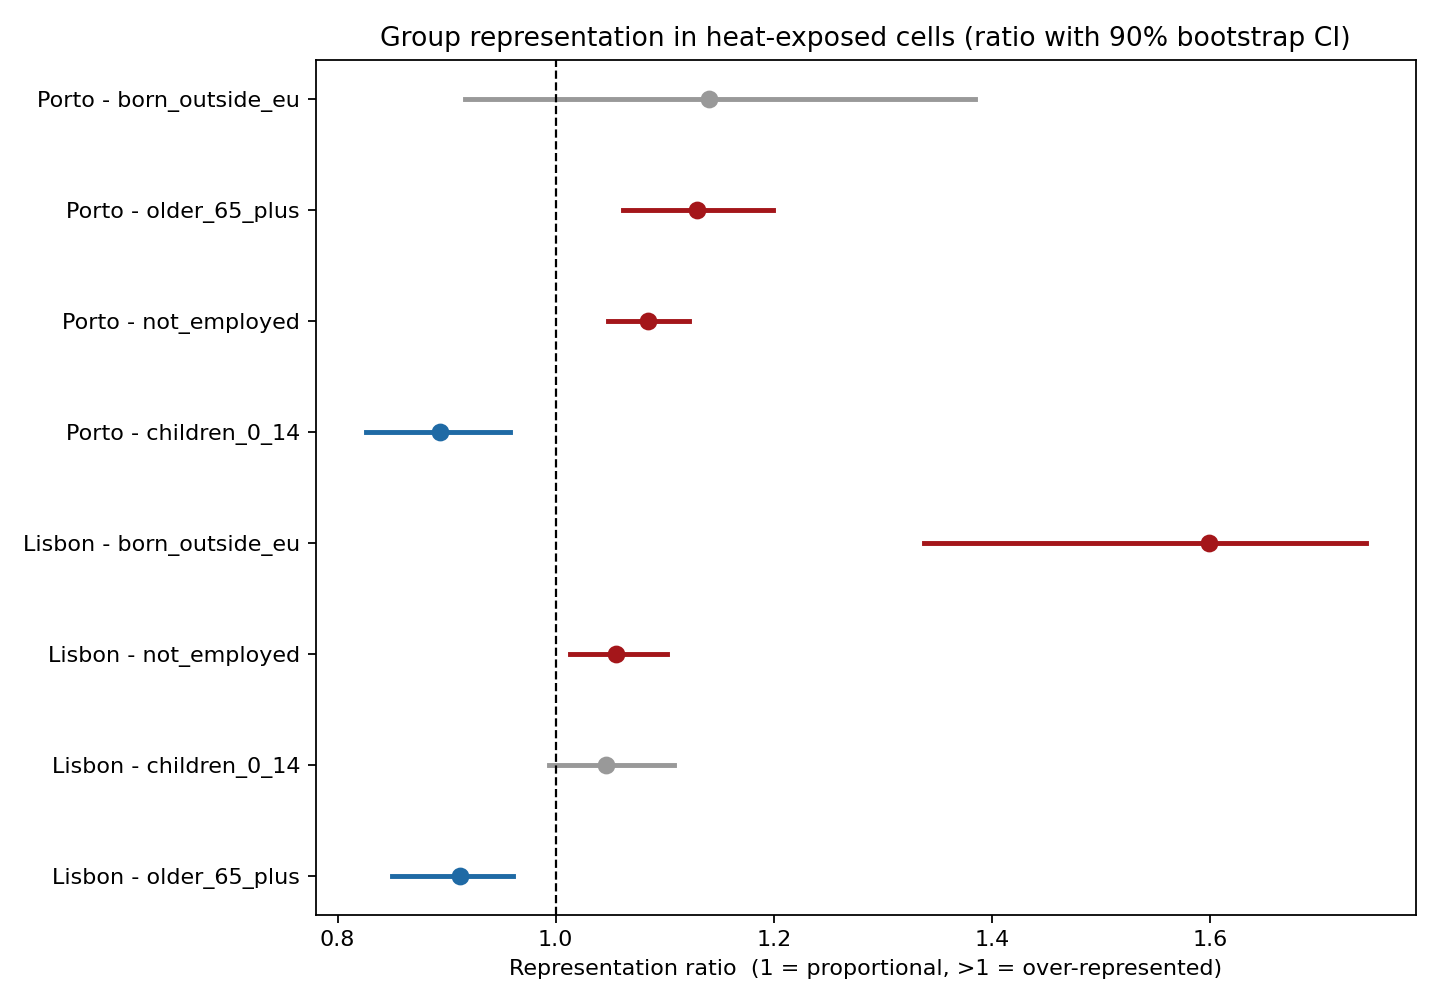

,city,group,representation_ratio,ci_low,ci_high,prob_overrepresented,significant
0,Lisbon,children_0_14,1.046,0.994,1.109,0.936,False
1,Lisbon,older_65_plus,0.912,0.850,0.961,0.010,True
2,Lisbon,not_employed,1.055,1.013,1.102,0.985,True
3,Lisbon,born_outside_eu,1.600,1.338,1.743,0.992,True
4,Porto,children_0_14,0.894,0.826,0.958,0.004,True
5,Porto,older_65_plus,1.130,1.061,1.199,1.000,True
6,Porto,not_employed,1.085,1.048,1.122,1.000,True
7,Porto,born_outside_eu,1.140,0.917,1.384,0.848,False


In [10]:
representation_ci = bootstrap_group_representation(
    cells, threshold=UHI_THRESHOLD_CELSIUS, n_boot=2000, ci=0.90, random_state=42,
)
ci_plot_path = PLOT_DIR / ("demo_representation_ci.png" if USE_DEMO
                           else "porto_lisbon_representation_ci.png")
plot_representation_with_ci(representation_ci, ci_plot_path)
display(Image(filename=ci_plot_path))
representation_ci.round(3)

**Reading this.** `ci_low`/`ci_high` are the 90% bootstrap interval for the representation
ratio; `prob_overrepresented` is the bootstrap probability the ratio exceeds 1; `significant`
is True when the interval is entirely on one side of 1. The picture is more cautious than the
raw ratios: Lisbon's born-outside-EU over-representation (1.6x) is strongly significant, but
Porto's born-outside-EU ratio is **not** distinguishable from proportional, and Lisbon's
children ratio is borderline. (Cells are spatially autocorrelated, so these intervals are
mildly optimistic — treat them as a screen.)

## A threshold-free check: dose-response

A single 2 C threshold is a modelling choice. As an independent check we ignore the threshold
entirely and measure how each group's **local population share** moves with a cell's UHI
intensity across **all** cells (population-weighted correlation and a slope in percentage
points of share per +1 C). A positive value means the group is concentrated in hotter cells.

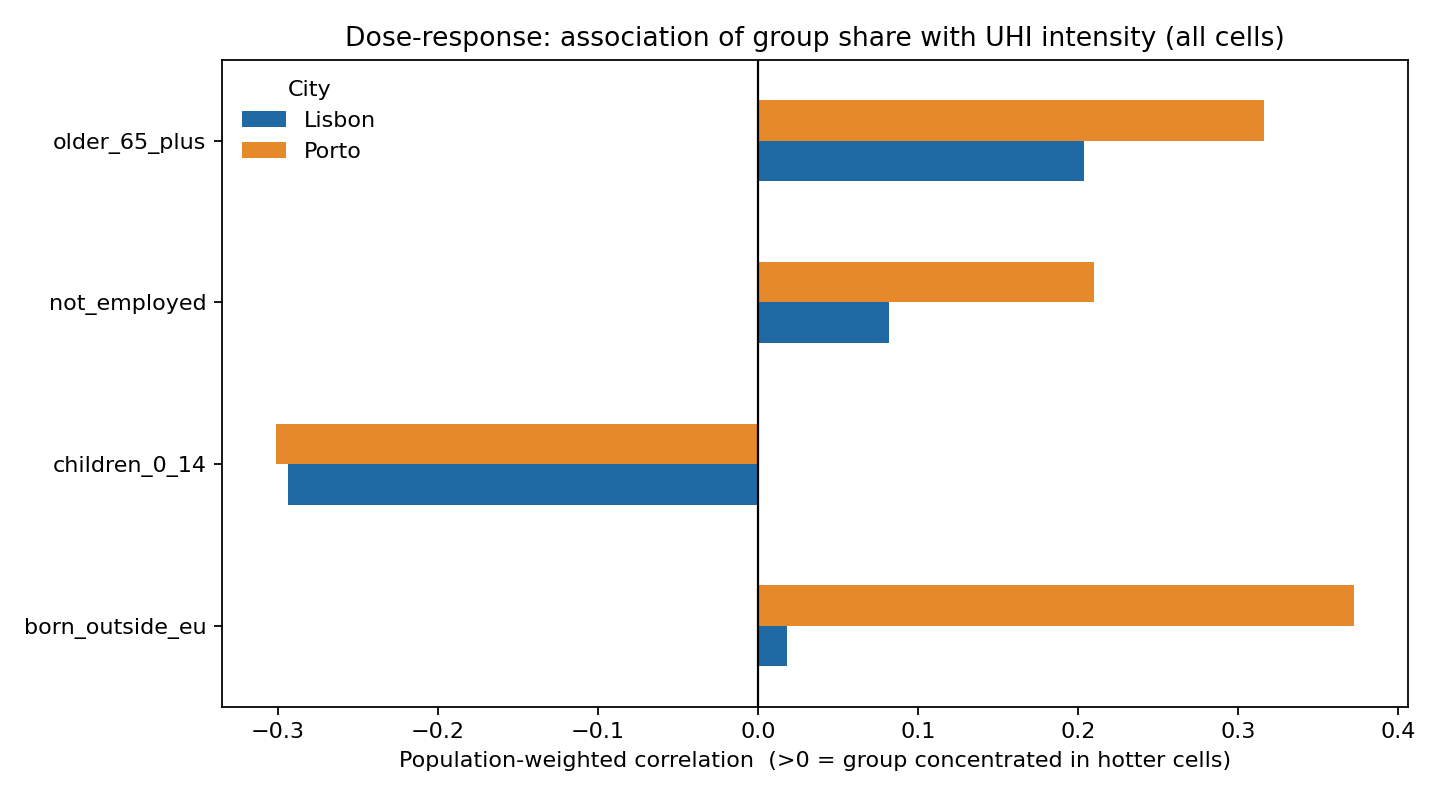

,city,group,weighted_corr_uhi_share,slope_pp_share_per_degree
0,Lisbon,children_0_14,-0.294,-1.272
1,Lisbon,older_65_plus,0.204,1.752
2,Lisbon,not_employed,0.082,0.536
3,Lisbon,born_outside_eu,0.018,0.157
4,Porto,children_0_14,-0.301,-1.653
5,Porto,older_65_plus,0.316,3.763
6,Porto,not_employed,0.210,2.309
7,Porto,born_outside_eu,0.372,3.331


In [11]:
dose_response = compute_dose_response(cells)
dose_plot_path = PLOT_DIR / ("demo_dose_response.png" if USE_DEMO
                             else "porto_lisbon_dose_response.png")
plot_dose_response(dose_response, dose_plot_path)
display(Image(filename=dose_plot_path))
dose_response.round(3)

**Reading this.** The continuous view sometimes **disagrees** with the threshold ratio, and
that is informative. Lisbon's born-outside-EU signal is near-zero on the gradient (correlation
~0.02) despite a high threshold ratio — it is an **extreme-tail** effect, driven by the few
hottest cells, not a city-wide gradient. In Porto, by contrast, older and migrant residents
show a clear positive gradient (correlation ~0.3-0.4) that rises smoothly with heat. Children
are negatively associated with heat in both cities.

## Threshold sensitivity table

This table shows why a single threshold can sometimes make the city comparison look sharper than the underlying distribution difference really is. Porto remains above Lisbon at every threshold shown here, but the gap widens materially once the threshold crosses `1.5 °C`.


In [12]:
threshold_sensitivity = compute_threshold_sensitivity(
    cells,
    thresholds=[1.0, 1.5, 2.0, 2.25],
)
threshold_sensitivity.pivot(index="threshold_celsius", columns="city", values="exposed_population_share").round(3)

city,Lisbon,Porto
threshold_celsius,,
1.00,0.600,0.889
1.50,0.230,0.592
2.00,0.011,0.064
2.25,0.000,0.004


## Highest-intensity populated fragments

These rows identify the hottest fragments that also matter demographically. This helps separate isolated hot spots from fragments where many residents are actually exposed.


In [13]:
top_hot_fragments = cells.loc[
    cells["population_total"] > 0,
    [
        "city",
        "cell_id",
        "population_total",
        "age_0_14",
        "age_65_plus",
        "employed",
        "born_outside_eu",
        "uhi_intensity_celsius",
        "is_uhi_exposed",
    ],
].sort_values(["uhi_intensity_celsius", "population_total"], ascending=[False, False])

top_hot_fragments.head(12).round(2)

,city,cell_id,population_total,age_0_14,age_65_plus,employed,born_outside_eu,uhi_intensity_celsius,is_uhi_exposed
1202,Porto,CRS3035RES1000mN2196000E2769000,3591.00,300.00,1123.00,1214.00,432.00,2.30,True
109,Lisbon,CRS3035RES1000mN1935000E2665000,5998.32,850.62,1186.10,2577.10,1331.12,2.23,True
1203,Porto,CRS3035RES1000mN2196000E2770000,3203.00,339.00,932.00,1084.00,221.00,2.23,True
95,Lisbon,CRS3035RES1000mN1934000E2668000,621.00,87.00,116.00,264.00,112.00,2.20,True
1159,Porto,CRS3035RES1000mN2197000E2773000,4365.00,542.00,1049.00,1328.00,144.00,2.19,True
1156,Porto,CRS3035RES1000mN2197000E2772000,2647.00,286.00,810.00,860.00,97.00,2.18,True
94,Lisbon,CRS3035RES1000mN1933000E2668000,464.00,108.00,49.00,78.00,83.00,2.18,True
1161,Porto,CRS3035RES1000mN2198000E2773000,7198.00,987.00,1811.00,2216.00,285.00,2.15,True
519,Lisbon,CRS3035RES1000mN1938000E2663000,3616.97,520.13,757.74,1460.57,1039.27,2.15,True
282,Lisbon,CRS3035RES1000mN1933000E2670000,83.64,26.50,7.45,37.26,1.66,2.15,True


## Group sensitivity across thresholds

The binary `2.0 °C` split is useful, but it can hide whether a result is stable or threshold-dependent. The next table and plot show how each group's representation ratio changes as the cutoff moves from milder to hotter fragments.


In [14]:
group_thresholds = np.arange(1.0, 2.26, 0.25)
group_representation_by_threshold = compute_group_representation_by_threshold(
    cells,
    thresholds=group_thresholds,
)

group_representation_by_threshold.head(12).round(3)

,city,group,city_group_count,exposed_group_count,city_group_share,exposed_group_share,difference_percentage_points,representation_ratio,is_overrepresented,threshold_celsius
0,Lisbon,children_0_14,259212.960,2860.391,0.140,0.147,0.651,1.046,True,1.00
1,Lisbon,older_65_plus,421156.529,4052.275,0.228,0.208,-1.991,0.912,False,1.00
2,Lisbon,not_employed,1049504.648,11677.866,0.567,0.598,3.131,1.055,True,1.00
3,Lisbon,born_outside_eu,284257.612,4794.455,0.154,0.246,9.207,1.600,True,1.00
4,Porto,children_0_14,118993.356,6832.000,0.124,0.111,-1.313,0.894,False,1.00
5,Porto,older_65_plus,216144.657,15677.000,0.226,0.255,2.924,1.130,True,1.00
6,Porto,not_employed,550619.284,38353.000,0.575,0.623,4.876,1.085,True,1.00
7,Porto,born_outside_eu,60815.938,4453.000,0.063,0.072,0.891,1.140,True,1.00
8,Lisbon,children_0_14,259212.960,2860.391,0.140,0.147,0.651,1.046,True,1.25
9,Lisbon,older_65_plus,421156.529,4052.275,0.228,0.208,-1.991,0.912,False,1.25


## Exposure decomposition by hot-tail band

This decomposition asks a different question: among residents already above the selected threshold, which temperature bands account for most of the exposed population? That helps distinguish a city with many mildly exposed residents from one where exposure is concentrated deeper in the hot tail.


In [15]:
exposure_band_decomposition = compute_exposure_band_decomposition(
    cells,
    threshold=UHI_THRESHOLD_CELSIUS,
    band_width=0.1,
)

exposure_band_decomposition.round(3)

,city,uhi_band,band_population,heat_excess_population,band_population_share_of_exposed,heat_excess_share_of_exposed
0,Lisbon,2.0-2.1,8570.246,179.410,0.439,0.075
2,Lisbon,2.2-2.3,6619.324,1533.812,0.339,0.644
1,Lisbon,2.1-2.2,4328.609,667.773,0.222,0.280
6,Porto,2.0-2.1,33877.000,809.570,0.551,0.138
7,Porto,2.1-2.2,20861.000,3239.464,0.339,0.553
9,Porto,2.3-2.4,3591.000,1079.997,0.058,0.185
8,Porto,2.2-2.3,3203.000,724.019,0.052,0.124


## Reconstructed spatial view

The prepared CSV does not store geometries, but the Eurostat grid cell ids encode them. This section reconstructs each 1 km square and uses that to create a pseudo-map of the UHI field, with the hottest populated fragments highlighted.


In [16]:
cells_geo = prepared_cells_to_geodataframe(cells)
cells_geo[["city", "cell_id", "uhi_intensity_celsius"]].head()

,city,cell_id,uhi_intensity_celsius
0,Lisbon,CRS3035RES1000mN1929000E2657000,0.140198
1,Lisbon,CRS3035RES1000mN1933000E2674000,1.645599
2,Lisbon,CRS3035RES1000mN1930000E2674000,1.669006
3,Lisbon,CRS3035RES1000mN1929000E2674000,1.477478
4,Lisbon,CRS3035RES1000mN1925000E2668000,1.265320


## Save outputs

This cell writes the city summary and the group representation table to `outputs/` so the numeric results can be reused outside the notebook.


In [17]:
summary_path = OUTPUT_DIR / ("demo_city_summary.csv" if USE_DEMO else "porto_lisbon_city_summary.csv")
representation_path = OUTPUT_DIR / ("demo_group_representation.csv" if USE_DEMO else "porto_lisbon_group_representation.csv")

write_dataframe(city_summary, summary_path)
write_dataframe(representation, representation_path)

summary_path, representation_path

(WindowsPath('C:/Users/diogo/work_code/ds-projects-portfolio/projects/porto_lisbon_uhi_exposure/outputs/porto_lisbon_city_summary.csv'),
 WindowsPath('C:/Users/diogo/work_code/ds-projects-portfolio/projects/porto_lisbon_uhi_exposure/outputs/porto_lisbon_group_representation.csv'))

## Visual diagnostics

The earlier tables answer the main binary-threshold question. The plots below go further and show:

1. how the full UHI distribution differs between Lisbon and Porto;
2. how much of each city's population sits in different UHI bands;
3. how sensitive the exposed-population comparison is to the chosen threshold;
4. which group differences are largest once the results are visualized side by side.


C:\Users\diogo\work_code\ds-projects-portfolio\projects\porto_lisbon_uhi_exposure\src\uhi_exposure\plotting.py:351: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


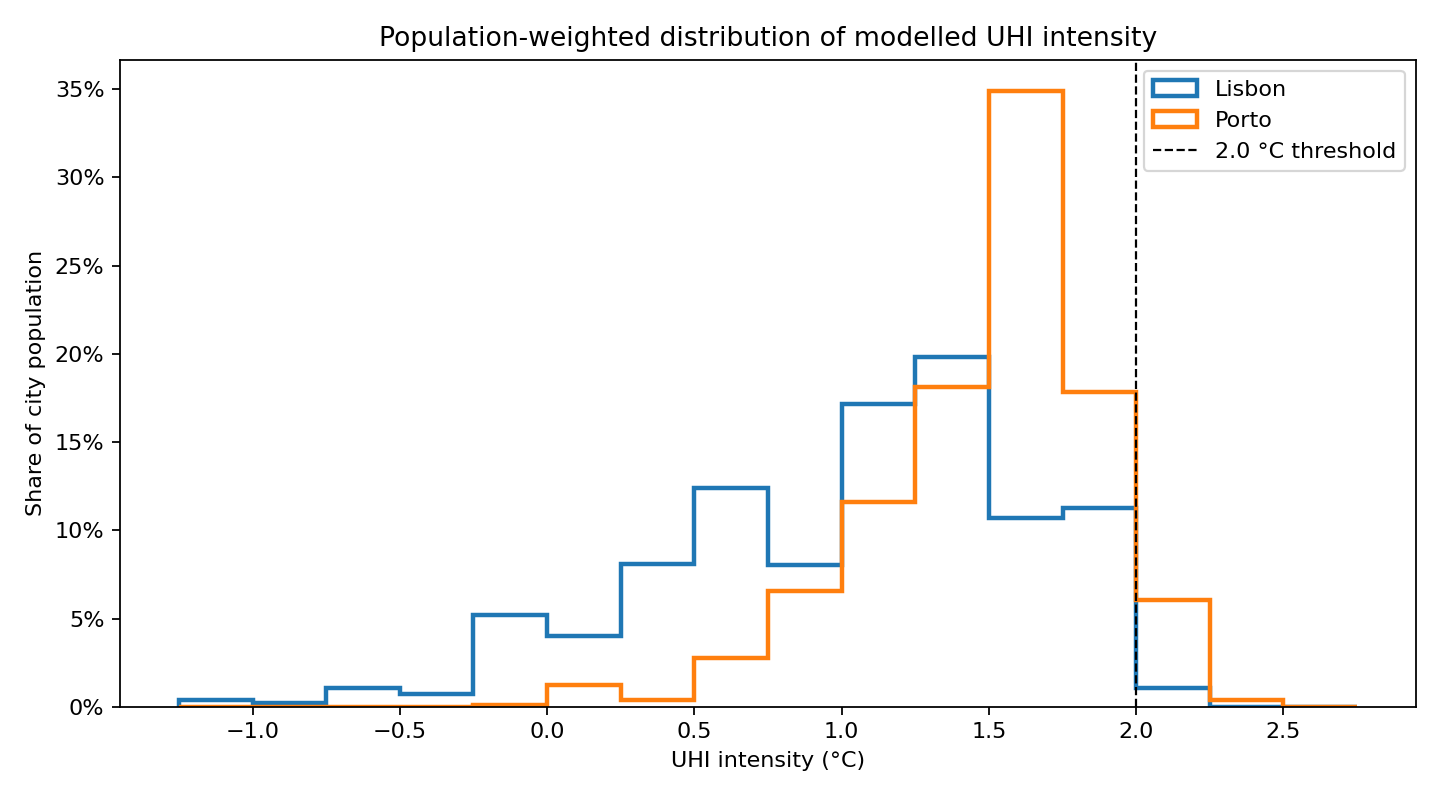

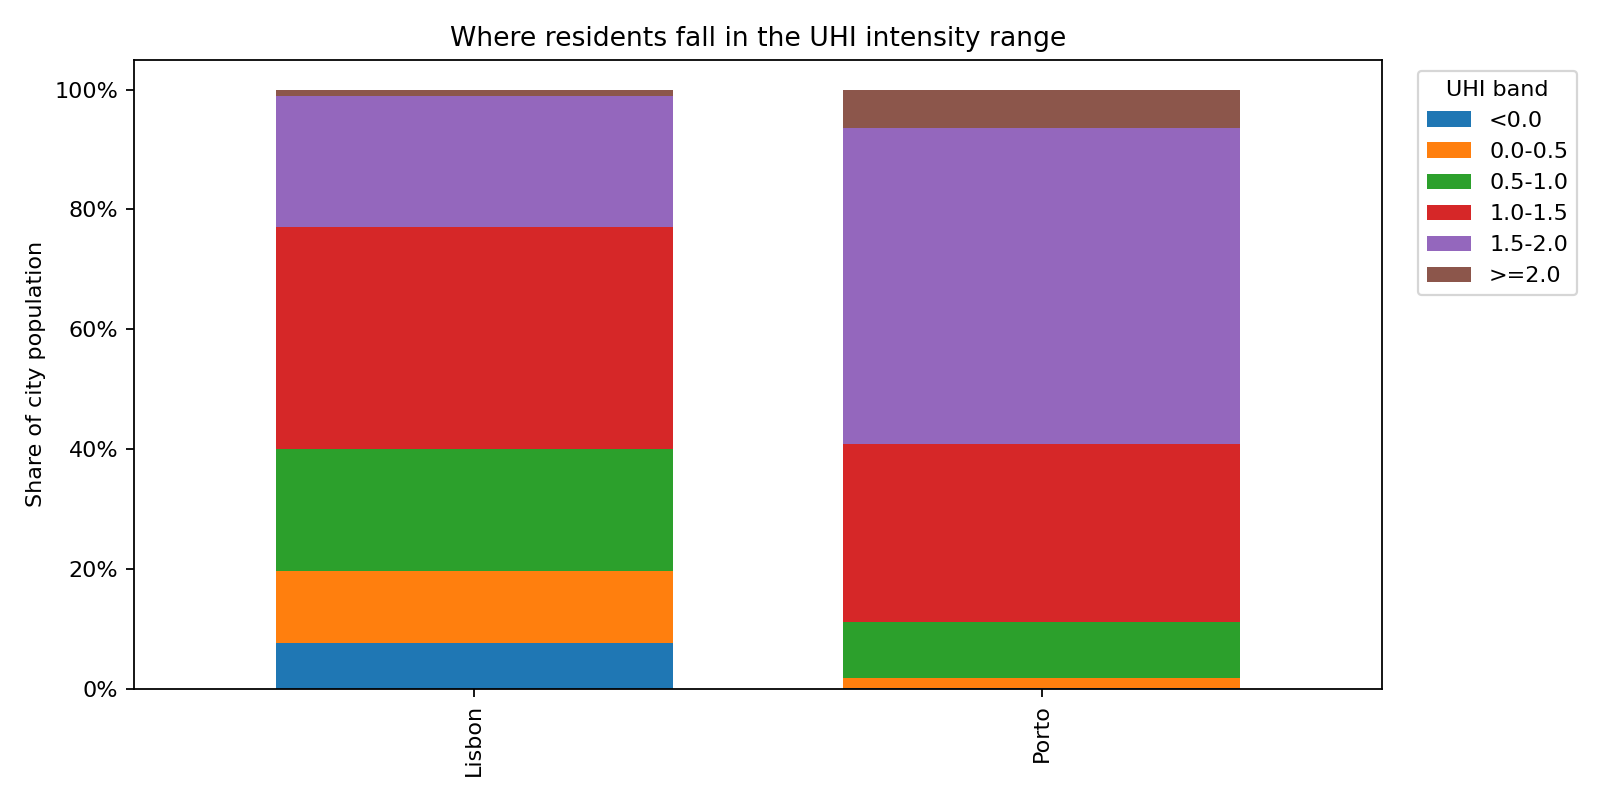

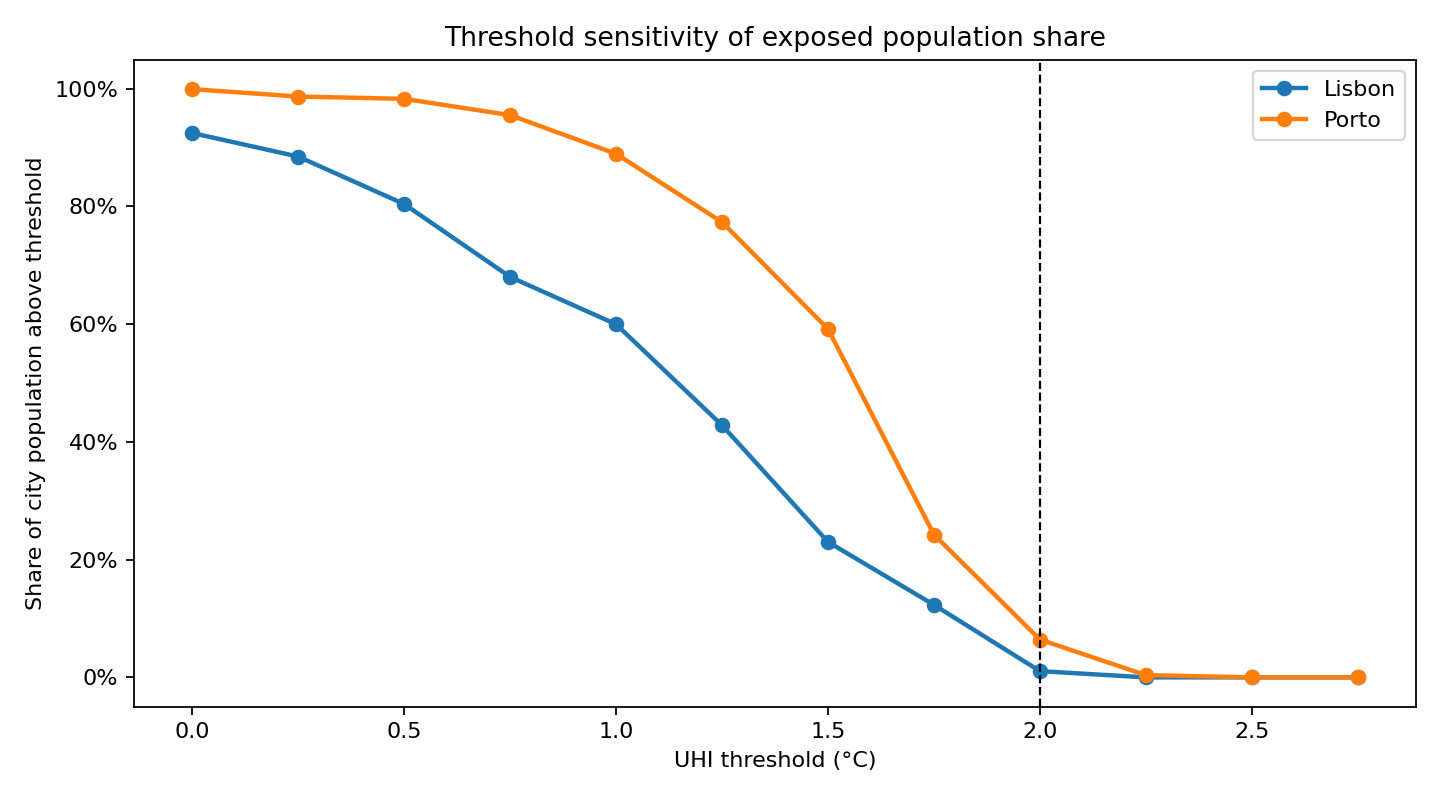

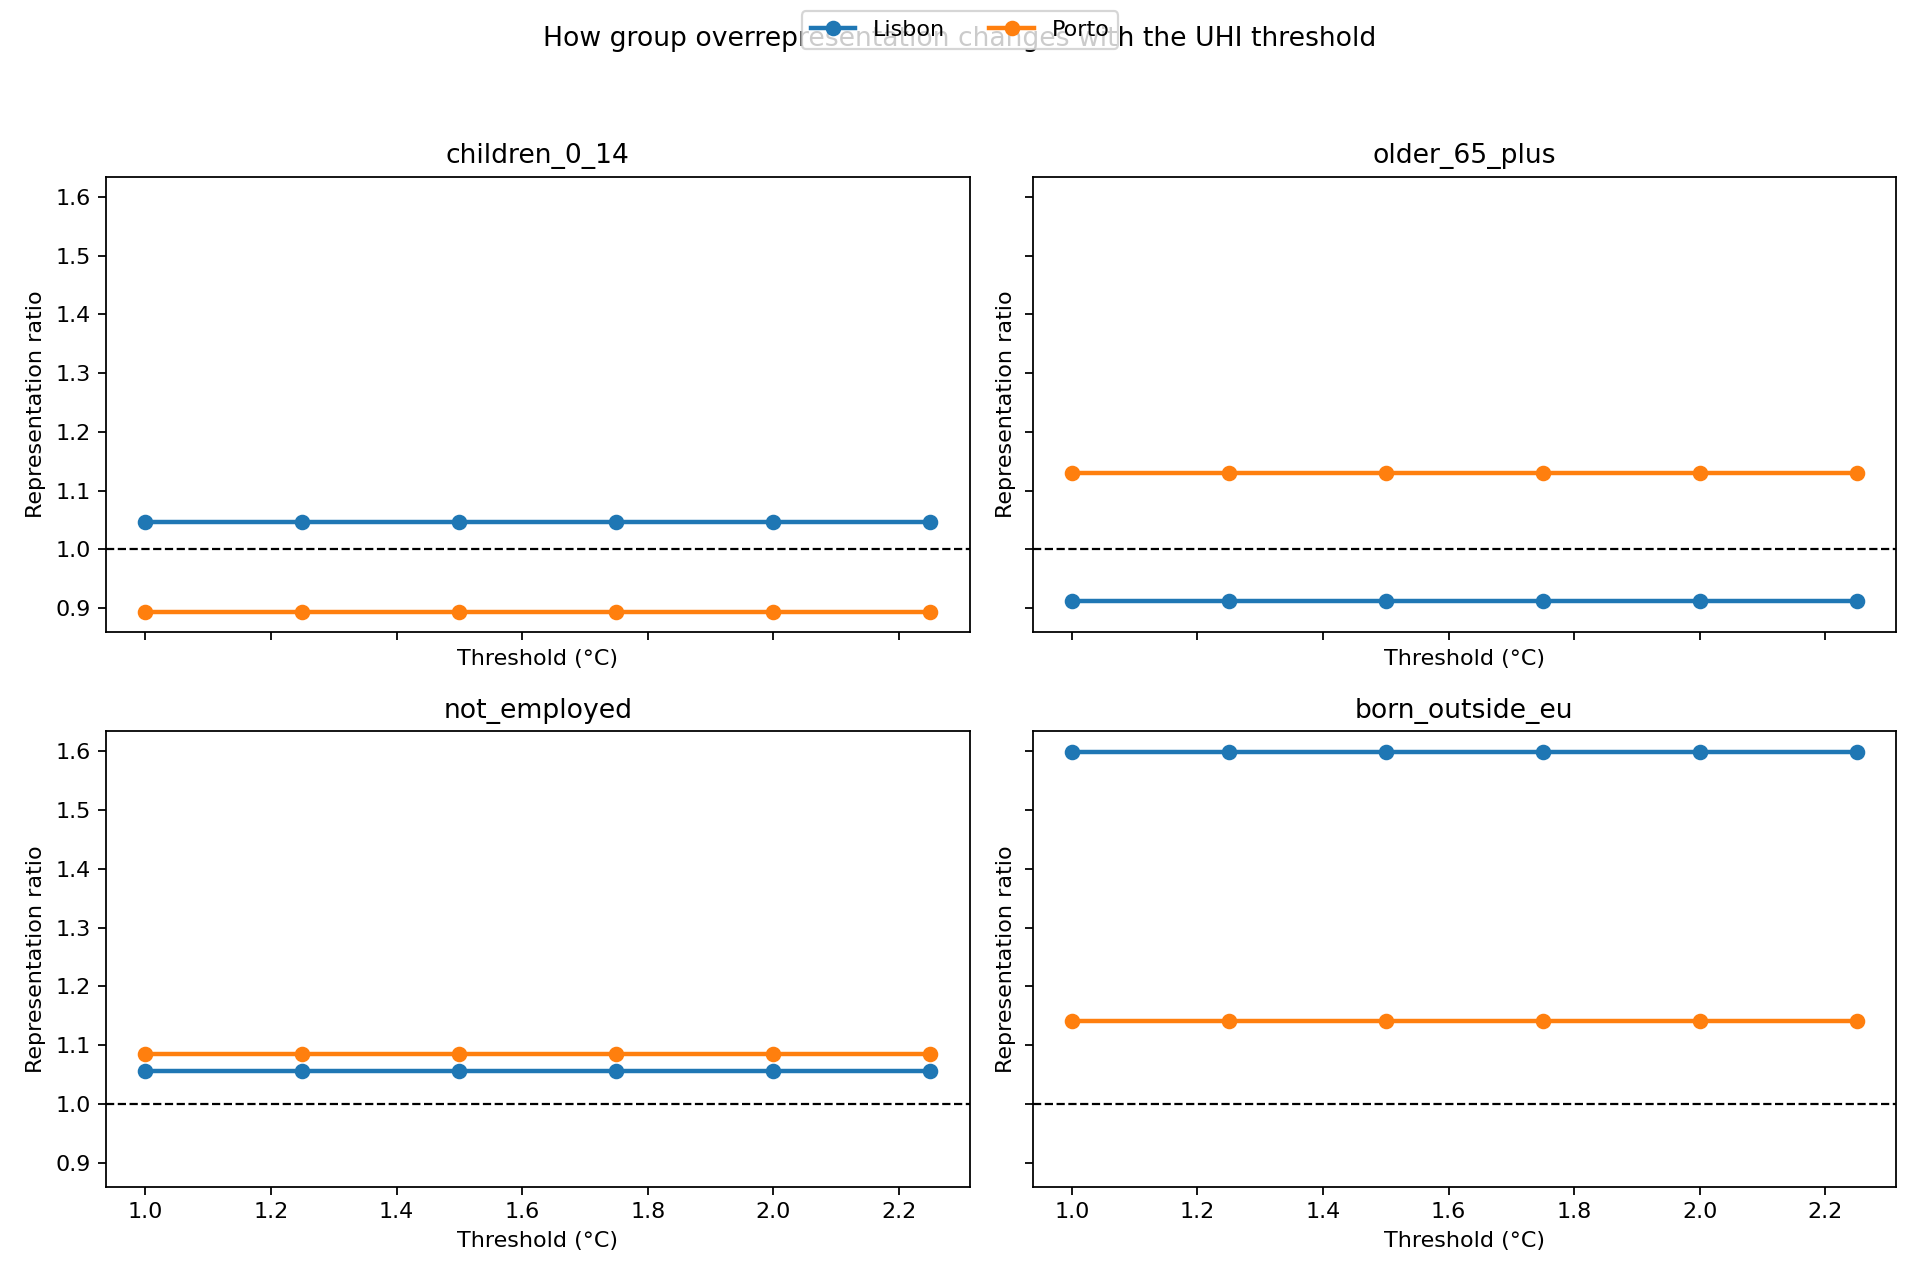

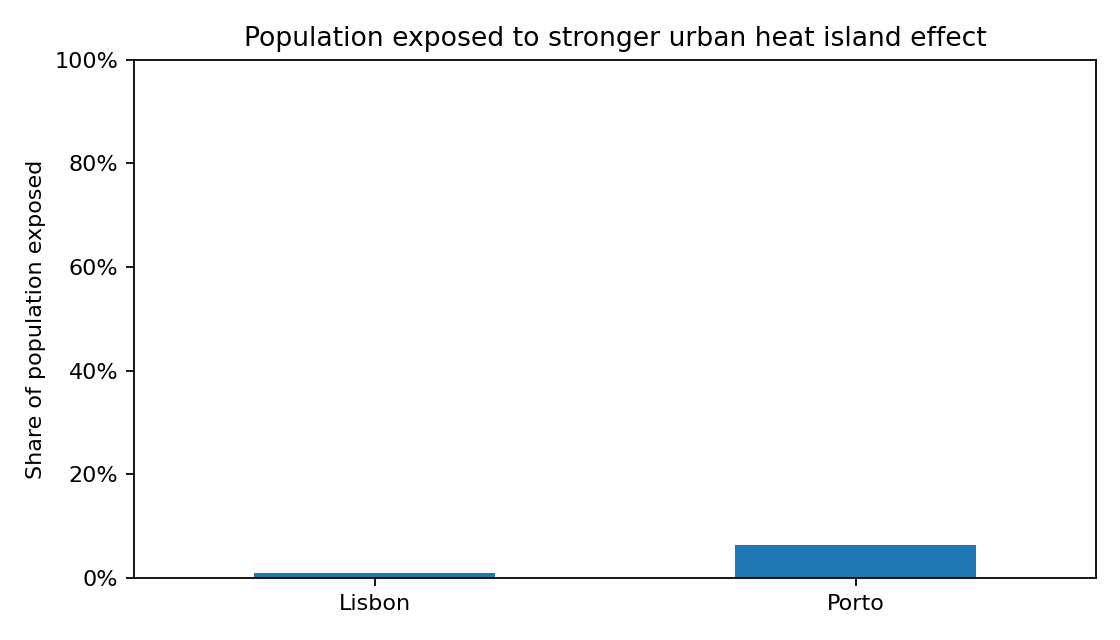

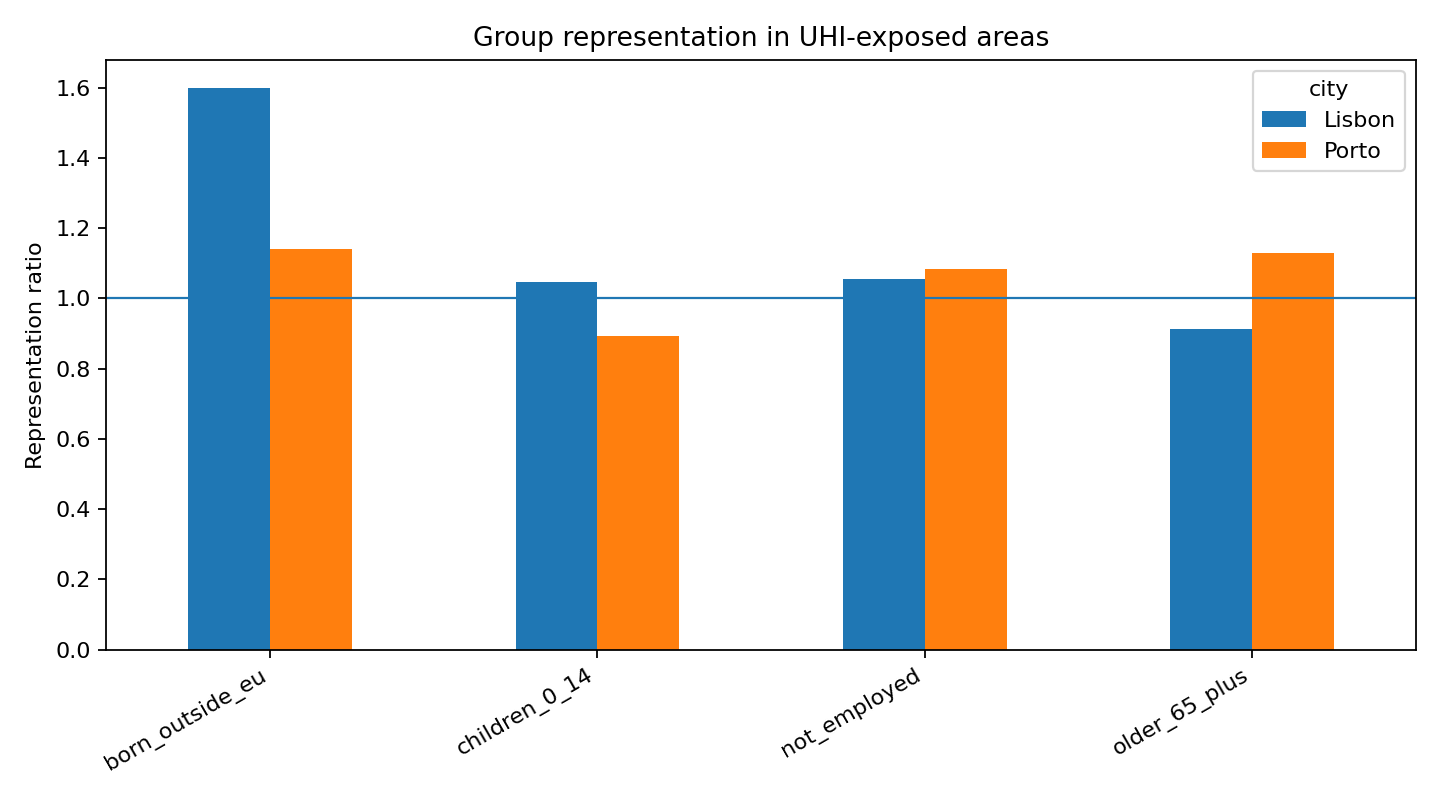

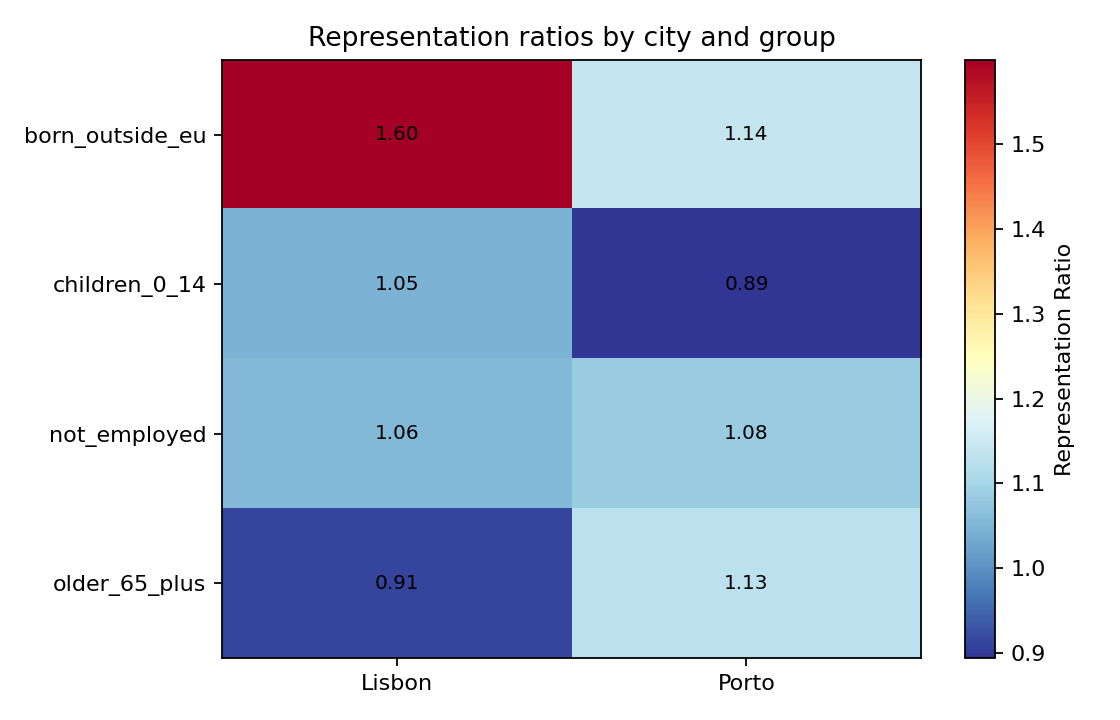

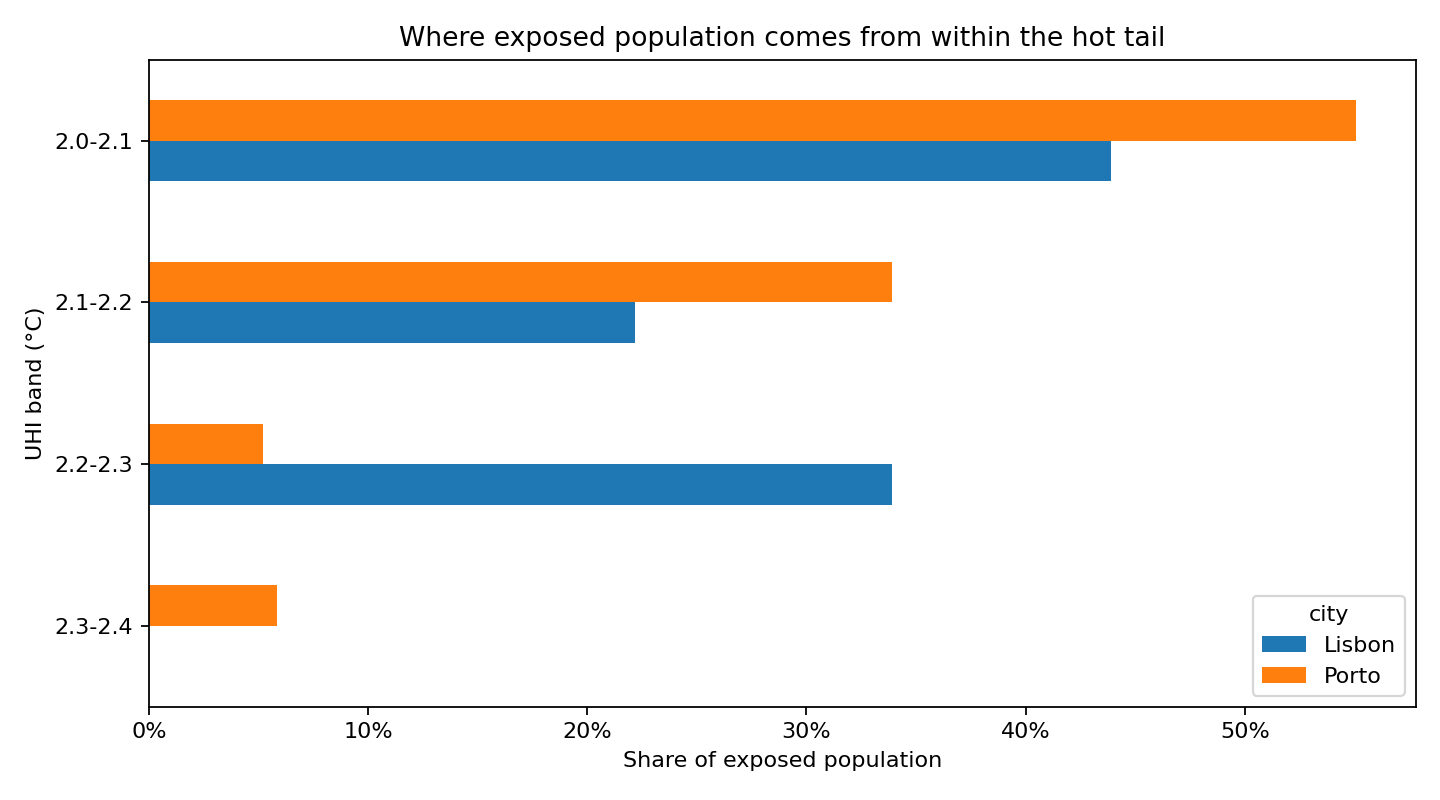

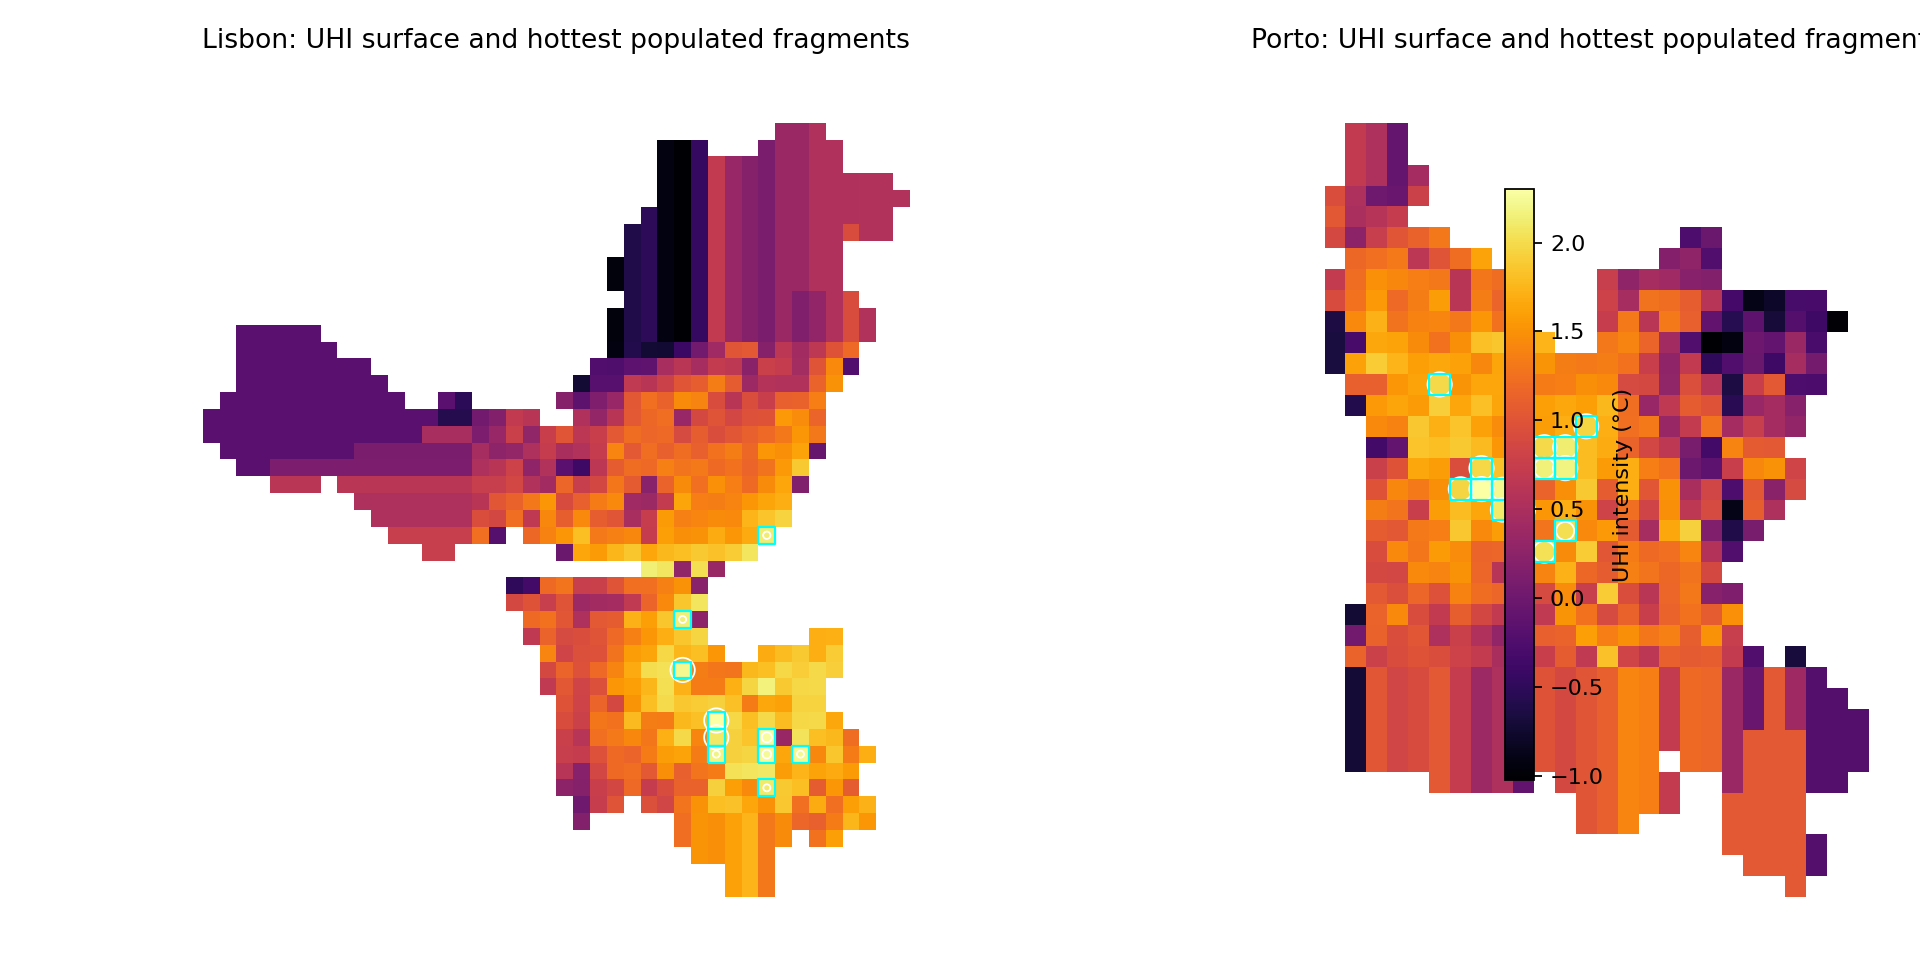

[WindowsPath('C:/Users/diogo/work_code/ds-projects-portfolio/projects/porto_lisbon_uhi_exposure/plots/demo_exposed_population_share.png'),
 WindowsPath('C:/Users/diogo/work_code/ds-projects-portfolio/projects/porto_lisbon_uhi_exposure/plots/demo_lisbon_group_share_comparison.png'),
 WindowsPath('C:/Users/diogo/work_code/ds-projects-portfolio/projects/porto_lisbon_uhi_exposure/plots/demo_porto_group_share_comparison.png'),
 WindowsPath('C:/Users/diogo/work_code/ds-projects-portfolio/projects/porto_lisbon_uhi_exposure/plots/demo_representation_ratios.png'),
 WindowsPath('C:/Users/diogo/work_code/ds-projects-portfolio/projects/porto_lisbon_uhi_exposure/plots/exposed_population_share.png'),
 WindowsPath('C:/Users/diogo/work_code/ds-projects-portfolio/projects/porto_lisbon_uhi_exposure/plots/lisbon_group_share_comparison.png'),
 WindowsPath('C:/Users/diogo/work_code/ds-projects-portfolio/projects/porto_lisbon_uhi_exposure/plots/porto_group_share_comparison.png'),
 WindowsPath('C:/Users/diog

In [18]:
plot_population_weighted_uhi_distribution(
    cells,
    PLOT_DIR / ("demo_population_weighted_uhi_distribution.png" if USE_DEMO else "porto_lisbon_population_weighted_uhi_distribution.png"),
)
plot_population_uhi_band_comparison(
    cells,
    PLOT_DIR / ("demo_population_uhi_band_comparison.png" if USE_DEMO else "porto_lisbon_population_uhi_band_comparison.png"),
)
plot_threshold_sensitivity(
    cells,
    PLOT_DIR / ("demo_threshold_sensitivity.png" if USE_DEMO else "porto_lisbon_threshold_sensitivity.png"),
)
plot_group_threshold_small_multiples(
    group_representation_by_threshold,
    PLOT_DIR / ("demo_group_threshold_small_multiples.png" if USE_DEMO else "porto_lisbon_group_threshold_small_multiples.png"),
)
plot_exposed_population_share(
    city_summary,
    PLOT_DIR / ("demo_exposed_population_share.png" if USE_DEMO else "porto_lisbon_exposed_population_share.png"),
)
plot_representation_ratios(
    representation,
    PLOT_DIR / ("demo_representation_ratios.png" if USE_DEMO else "porto_lisbon_representation_ratios.png"),
)
plot_representation_heatmap(
    representation,
    PLOT_DIR / ("demo_representation_heatmap.png" if USE_DEMO else "porto_lisbon_representation_heatmap.png"),
)
plot_exposure_band_decomposition(
    exposure_band_decomposition,
    PLOT_DIR / ("demo_exposure_band_decomposition.png" if USE_DEMO else "porto_lisbon_exposure_band_decomposition.png"),
)
plot_hotspot_map(
    cells_geo,
    PLOT_DIR / ("demo_hotspot_map.png" if USE_DEMO else "porto_lisbon_hotspot_map.png"),
)

for city in sorted(representation["city"].unique()):
    safe_city = city.lower().replace(" ", "_")
    plot_group_share_comparison(
        representation,
        city=city,
        output_path=PLOT_DIR / (f"demo_{safe_city}_group_share_comparison.png" if USE_DEMO else f"{safe_city}_group_share_comparison.png"),
    )

plot_files = [
    PLOT_DIR / ("demo_population_weighted_uhi_distribution.png" if USE_DEMO else "porto_lisbon_population_weighted_uhi_distribution.png"),
    PLOT_DIR / ("demo_population_uhi_band_comparison.png" if USE_DEMO else "porto_lisbon_population_uhi_band_comparison.png"),
    PLOT_DIR / ("demo_threshold_sensitivity.png" if USE_DEMO else "porto_lisbon_threshold_sensitivity.png"),
    PLOT_DIR / ("demo_group_threshold_small_multiples.png" if USE_DEMO else "porto_lisbon_group_threshold_small_multiples.png"),
    PLOT_DIR / ("demo_exposed_population_share.png" if USE_DEMO else "porto_lisbon_exposed_population_share.png"),
    PLOT_DIR / ("demo_representation_ratios.png" if USE_DEMO else "porto_lisbon_representation_ratios.png"),
    PLOT_DIR / ("demo_representation_heatmap.png" if USE_DEMO else "porto_lisbon_representation_heatmap.png"),
    PLOT_DIR / ("demo_exposure_band_decomposition.png" if USE_DEMO else "porto_lisbon_exposure_band_decomposition.png"),
    PLOT_DIR / ("demo_hotspot_map.png" if USE_DEMO else "porto_lisbon_hotspot_map.png"),
]
for plot_file in plot_files:
    display(Image(filename=plot_file))

sorted(PLOT_DIR.glob("demo_*.png" if USE_DEMO else "*.png"))

The expanded visual set makes three additional points visible.

1. Some representation results are **stable across thresholds**, while others only appear once the cutoff moves into the hottest tail.
2. The exposed population is not evenly spread across the hot tail; the decomposition shows whether exposure is clustered just above the threshold or extends into hotter bands.
3. The reconstructed grid view helps separate broad warm zones from a smaller set of very hot populated fragments.


## Real-data rebuild notes

The geospatial preparation is implemented in `scripts/prepare_real_data.py`.

Run it when you want to refresh `data/manual/porto_lisbon_cells.csv` from source data instead of reusing the prepared table:

```bash
poetry run python scripts/prepare_real_data.py --output data/manual/porto_lisbon_cells.csv --threshold 2.0
```


## Double burden: where heat and vulnerability coincide

Heat exposure and demographic vulnerability are usually reported separately. Splitting each
city's cells at the population-weighted median of UHI intensity **and** of the heat-vulnerable
age share (children plus over-65s) gives four quadrants. The "high heat + high vulnerability"
quadrant is the **double burden** — heat falling on the residents least able to cope.

In [19]:
double_burden = compute_double_burden(cells)
write_dataframe(
    double_burden,
    OUTPUT_DIR / ("demo_double_burden.csv" if USE_DEMO else "porto_lisbon_double_burden.csv"),
)
double_burden.round(3)

,city,quadrant,population,population_share,mean_uhi_celsius
0,Lisbon,high heat + high vulnerability (double burden),491486.652,0.266,1.526
1,Lisbon,high heat + low vulnerability,435170.650,0.235,1.531
2,Lisbon,low heat + high vulnerability,446831.344,0.241,0.608
3,Lisbon,low heat + low vulnerability,477510.726,0.258,0.461
4,Porto,high heat + high vulnerability (double burden),287826.198,0.300,1.816
5,Porto,high heat + low vulnerability,196794.212,0.205,1.762
6,Porto,low heat + high vulnerability,193685.320,0.202,1.230
7,Porto,low heat + low vulnerability,280052.952,0.292,1.204


**Reading this.** If heat and vulnerability were independent, each quadrant would hold ~25%
of the population. In Porto the double-burden quadrant holds **~30%** — vulnerable residents
are disproportionately in the hotter half of the city. Lisbon is closer to the ~25% null,
consistent with its concern being concentrated in a narrower migrant-heavy tail rather than
spread across the vulnerable-age population.

## Conclusions

Reading the representation ratios **with their bootstrap confidence intervals** changes which
findings actually survive:

1. **Porto carries the larger and broader heat burden.** A much bigger share of its population
   sits above the 2 C threshold than Lisbon (~6.4% vs ~1.1%), and ~30% of Porto residents fall
   in the high-heat + high-vulnerability double-burden quadrant (vs the 25% a no-association
   null would give).
2. **In Lisbon, residents born outside the EU are significantly over-represented in exposed
   cells (1.6x, 90% CI excludes 1)** — the single strongest signal in the study. In **Porto**
   the same group's threshold ratio is *not* statistically distinguishable from proportional
   (CI includes 1), so the earlier "both cities" reading does **not** hold at the threshold.
3. **Older residents** are significantly over-represented in Porto's hot cells but significantly
   *under*-represented in Lisbon's — the two cities genuinely differ.
4. **The threshold and the continuous dose-response disagree, informatively.** Lisbon's
   born-outside-EU result is an *extreme-tail* effect (flat gradient overall, high ratio in the
   few hottest cells); Porto's elderly and migrant concentration instead rises *smoothly* with
   heat across the whole gradient.
5. **Children are consistently *under*-represented** in the hottest cells in both cities.

One-line summary: **in Lisbon the heat-equity concern is concentrated among residents born
outside the EU and confined to a small hot tail; in Porto it is broader (older and non-employed
residents), rises with heat across the city, and touches a far larger share of the population.**
These conclusions hold for the Urban Audit city polygons and the published UrbClim service, not
the municipalities people informally mean by "Lisbon" and "Porto".

## Caveats

- The threshold is a modelling decision, not a natural law.
- The output inherits the strengths and limits of the Eurostat grid and the published UrbClim service.
- Area-weighted fragments create fractional counts by construction.
- Results can differ sharply from municipality-based expectations because the Urban Audit city polygons are larger than municipal boundaries.
- Confidence intervals come from a cell-level bootstrap; neighbouring cells are spatially correlated, so the true intervals are somewhat wider than reported.